In [12]:
# meeting 2 tasks:
# practice by parsing elexon data from last 24h and combine relevant columns to form the 'matrix'


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# assign variable to store file path
# we have past week + past 10 year files. check filename to distinguish. no issues with loading the data
file_path = 'GenerationByFuelType-2016-01-01T00_00_00.000Z-2026-06-15T14_30_00.000Z.csv'

# reads a csv file into a DataFrame
# a DataFrame is a 2D array and used for larger data sets 
df = pd.read_csv(file_path)



In [9]:
# DataFrame functions:

# prints first 5 rows by default (data appears formatted compared to printing it)
#print('First 5 Rows: \n')
#print(df.head(100))
#print('\n')


print('All Info about DataFrame: \n')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3026972 entries, 0 to 3026971
Data columns (total 7 columns):
 #   Column            Dtype
---  ------            -----
 0   Dataset           str  
 1   PublishTime       str  
 2   StartTime         str  
 3   SettlementDate    str  
 4   SettlementPeriod  int64
 5   FuelType          str  
 6   Generation        int64
dtypes: int64(2), str(5)
memory usage: 161.7 MB


In [13]:
# pivot the data (long to wide format) i.e choose index labels (listed along side), column labels (listed across top) and values to fill the table 

# clean column names of empty spaces
df.columns = df.columns.str.strip()

# apply pivot function
df_pivot = df.pivot_table(
    index = ['SettlementDate', 'SettlementPeriod'],
    columns = 'FuelType',
    values = 'Generation',
    aggfunc = sum
)

# turn row labels back into columns
df_pivot = df_pivot.reset_index()



In [14]:
# check the pivoted data

print('First 5 rows: \n')
print(df_pivot.head())
print('\n')

df_pivot.info()

First 5 rows: 

FuelType SettlementDate  SettlementPeriod  BIOMASS    CCGT    COAL  INTELE  \
0            2016-01-01                 1      NaN  5716.0  3434.0     NaN   
1            2016-01-01                 2      NaN  6670.0  3583.0     NaN   
2            2016-01-01                 3      NaN  6985.0  3865.0     NaN   
3            2016-01-01                 4      NaN  6839.0  3772.0     NaN   
4            2016-01-01                 5      NaN  6775.0  3555.0     NaN   

FuelType  INTELEC  INTEW   INTFR  INTGRNL  ...  INTNEM  INTNSL  INTVKL  \
0             NaN  104.0  1756.0      NaN  ...     NaN     NaN     NaN   
1             NaN   26.0  1756.0      NaN  ...     NaN     NaN     NaN   
2             NaN   36.0  1756.0      NaN  ...     NaN     NaN     NaN   
3             NaN   64.0  1756.0      NaN  ...     NaN     NaN     NaN   
4             NaN   20.0  1756.0      NaN  ...     NaN     NaN     NaN   

FuelType  NPSHYD  NUCLEAR  OCGT  OIL   OTHER     PS    WIND  
0       

In [15]:
# combine relevant columns

# gas column
df_pivot ['Gas'] = df_pivot ['OCGT'] + df_pivot ['CCGT']


# interconnector column
int_columns = df_pivot.filter(like = 'INT') 
#print(int_columns)
df_pivot ['Int'] =  int_columns.sum(axis = 1) #axis=1 means add horizontally (for each row)


# hydroelectric column
df_pivot ['Hydro'] = df_pivot ['NPSHYD'] 

In [16]:
# create the final matrix

# copy columns to the final dataframe
final_matrix_df = df_pivot[
    ['SettlementDate', 
    'SettlementPeriod', 
    'Gas', 
    'NUCLEAR', 
    'Int', 
    'BIOMASS', 
    'Hydro',
     'COAL',
     'OIL',
     'PS',
     'WIND',
    'OTHER']
].copy()

# rename columns
final_matrix_df = final_matrix_df.rename(columns={
    'SettlementDate': 'Date',
    'SettlementPeriod': 'Period',
    'NUCLEAR': 'Nuclear',
    'BIOMASS': 'Biomass',
    'OIL':'Oil',
    'COAL':'Coal',
    'PS':'Pump Storage',
    'WIND':'Wind',
    'OTHER': 'Other'
})


final_matrix_df = final_matrix_df.sort_values(by=['Date', 'Period']) #sort by date first and then period
print(final_matrix_df.head(48)) # for a day



FuelType        Date  Period      Gas  Nuclear     Int  Biomass   Hydro  \
0         2016-01-01       1   5716.0   8289.0  2756.0      NaN   710.0   
1         2016-01-01       2   6670.0   8292.0  2688.0      NaN   659.0   
2         2016-01-01       3   6985.0   8297.0  2742.0      NaN   643.0   
3         2016-01-01       4   6839.0   8285.0  2694.0      NaN   642.0   
4         2016-01-01       5   6775.0   8279.0  2554.0      NaN   642.0   
5         2016-01-01       6   6897.0   8276.0  2560.0      NaN   642.0   
6         2016-01-01       7   7340.0   8266.0  2452.0      NaN   665.0   
7         2016-01-01       8   6927.0   8254.0  2466.0      NaN   862.0   
8         2016-01-01       9   6510.0   8236.0  2468.0      NaN   934.0   
9         2016-01-01      10   6137.0   8230.0  2496.0      NaN   960.0   
10        2016-01-01      11   6038.0   8216.0  2558.0      NaN   960.0   
11        2016-01-01      12   5833.0   8216.0  2598.0      NaN   961.0   
12        2016-01-01     

Summer Day vs Winter Day:




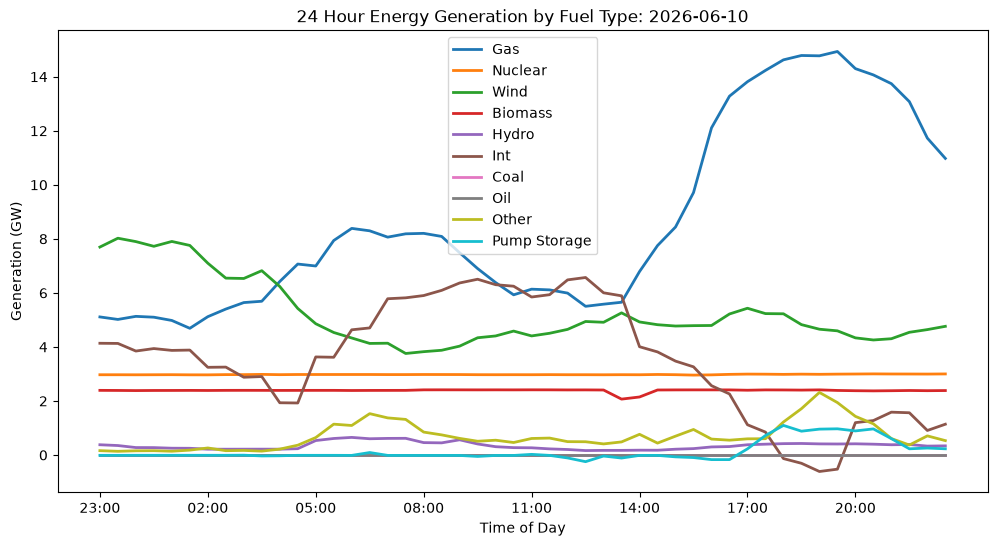

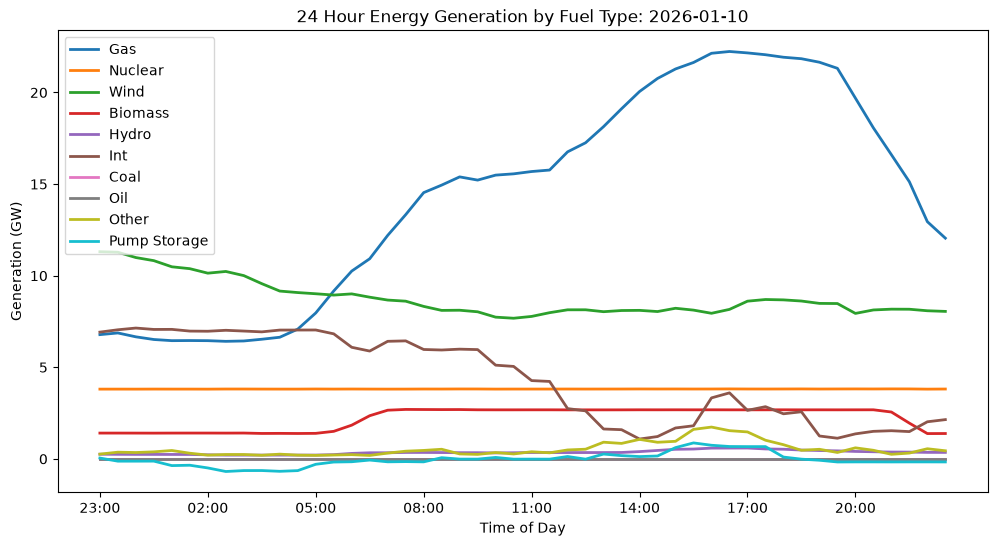







recent day vs old day:




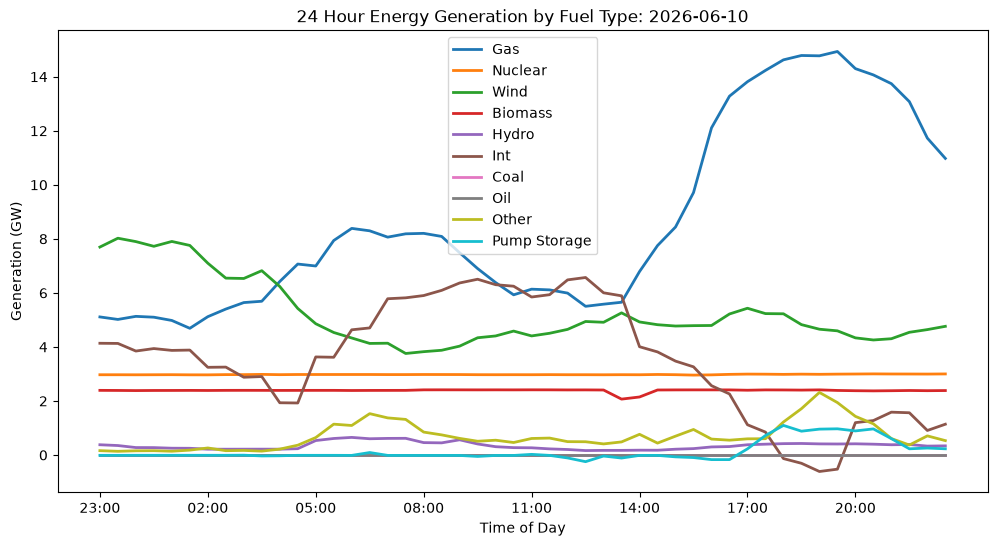

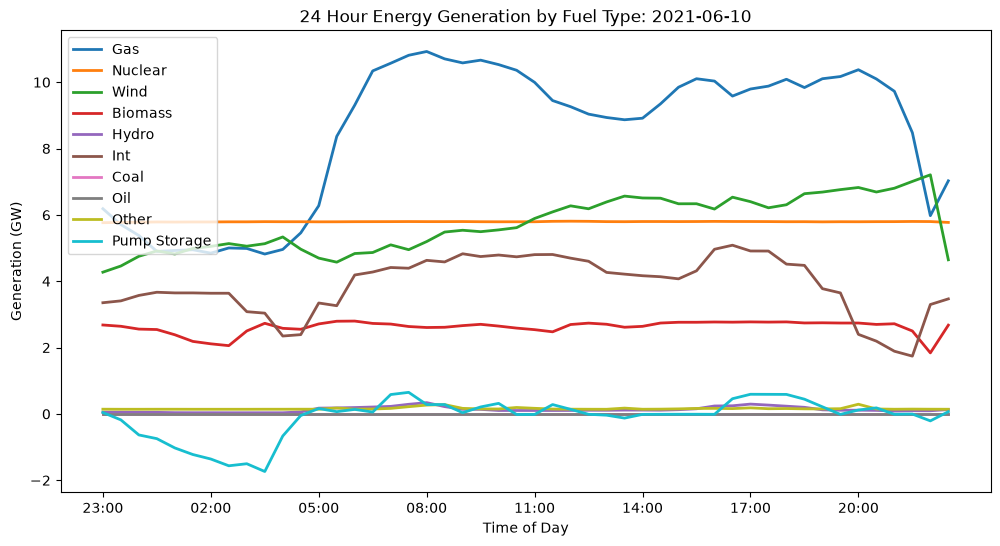

--------------------------------------------------------------------------


In [17]:
# meeting 3 task: will plot over 24 hrs    
    
def plot_some_day(date):  
    
    # select some day    
    day = date
    date_column = (final_matrix_df['Date']) # prints out the date_column in final matrix
    boolean_date_col  = date_column == day # returns boolean values in place of column
    #print(boolean_date_col.head())
    
    one_day = final_matrix_df[boolean_date_col].copy() # final matrix but only the rows for that day
    #print(one_day.head())
    
    # hard code times
    time_labels = [
        '23:00', '23:30', '00:00', '00:30', '01:00', '01:30', '02:00', '02:30', 
        '03:00', '03:30', '04:00', '04:30', '05:00', '05:30', '06:00', '06:30', 
        '07:00', '07:30', '08:00', '08:30', '09:00', '09:30', '10:00', '10:30', 
        '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', 
        '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', 
        '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30']
    
    # sort so that 23:00 matches 1 
    one_day = one_day.sort_values('Period') # sorts ascending by default
    
    # create a new column
    one_day ['Time'] = time_labels
    #print('With time column: \n')
    #print(one_day.head())
    
    # so that plot is big enough
    plt.figure(figsize=(12, 6))
    
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind',  'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = one_day['Time'] # acess values in time column
        y_values = one_day[fuel] / 1000  # access values in the fueltype + convert to GW
        plt.plot(x_values, y_values, label=fuel, linewidth=2) # draw a line
    
    
    # generate plots
    plt.title(f'24 Hour Energy Generation by Fuel Type: {day}')
    plt.ylabel('Generation (GW)')
    plt.xlabel('Time of Day')
    plt.xticks(ticks = range (0, 48, 6)) # show certain time column values
    plt.yticks()
    plt.legend()
    plt.show()


# choose some day 
print('Summer Day vs Winter Day:')
print('\n')

summer_day = '2026-06-10'
winter_day = '2026-01-10'

plot_some_day(summer_day)
print('\n')

plot_some_day(winter_day)
print('\n\n\n\n\n')


print('recent day vs old day:')
print('\n')

new_day = '2026-06-10'
old_day = '2021-06-10'

plot_some_day(new_day)
print('\n')

plot_some_day(old_day)


print('--------------------------------------------------------------------------')


Summer Week vs Winter Week:
---------------------------


Summer:


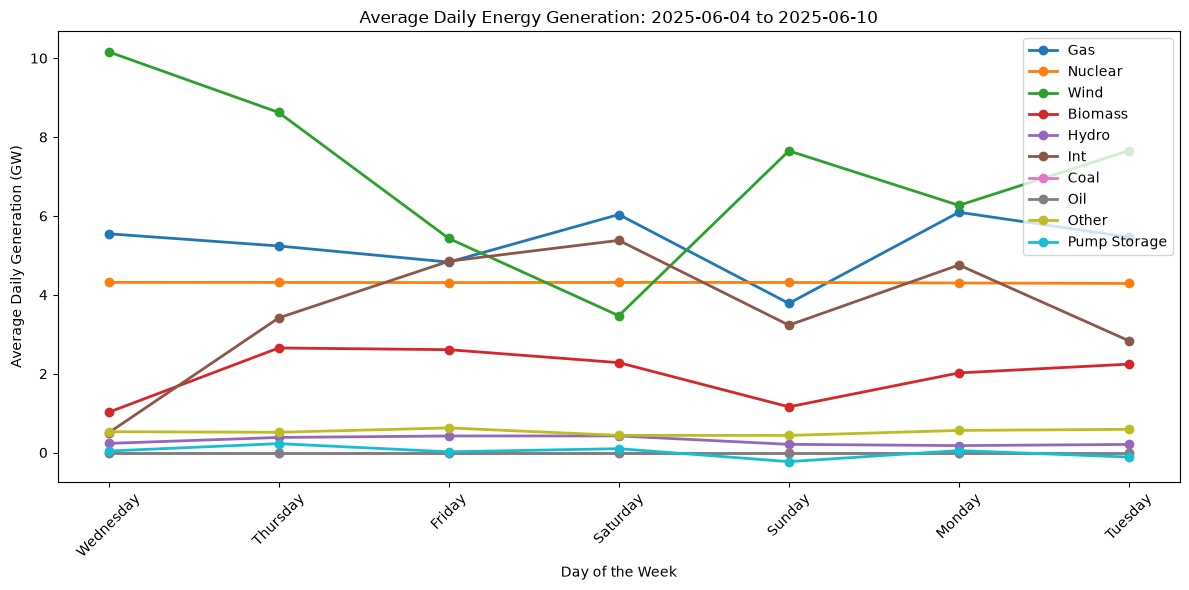


 
 
Winter:


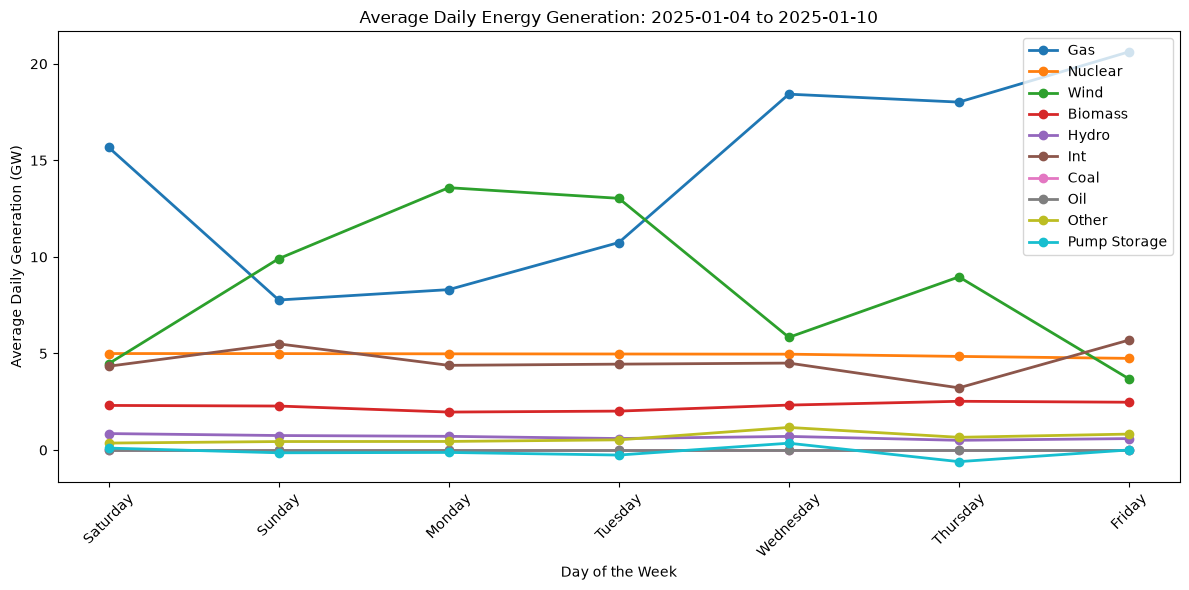


 
 

 
 
Recent Week vs Old Week (Summer Vs Winter):
-------------------------------------------


Recent:


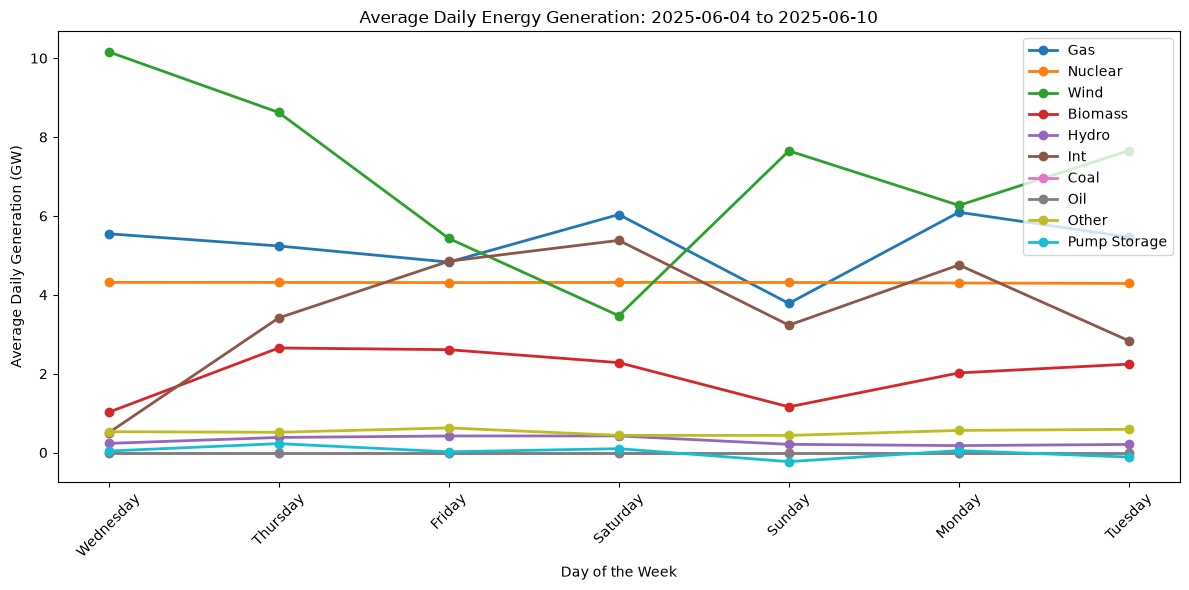


 
 
Old:


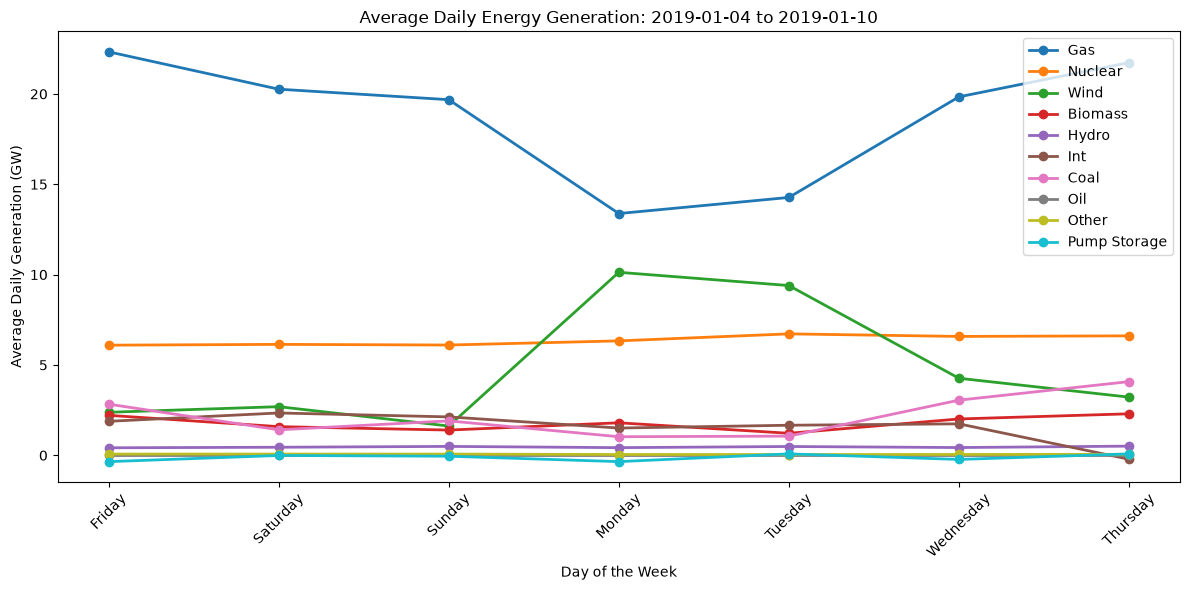

In [18]:
# meeting 4 tasks: will plot over a week


#print(final_matrix_df.head(48)) # for a day, will need to average all values meaning there will be only one value over 48 settlement period


def plot_week_average(start_date, end_date):  
    
    #print(f'Averaging data from {start_date} to {end_date}')
    date_column = final_matrix_df['Date'] 
    
    # returns boolean column
    boolean_date_col = (date_column >= start_date) & (date_column <= end_date)
    
    week_data = final_matrix_df[boolean_date_col].copy() # final matrix but only the rows for that week
    #print (week_data.head(500)) # 7 * 48 rows predicted
    #print (f'Found {len(week_data)} rows of data in this range.') # matches !

    
    
    # convert the date column to pandas datetime objects so it can be manipulated later
    #print (week_data['Date'])
    week_data['Date'] = pd.to_datetime(week_data['Date'])
    #print (week_data['Date'])


    daily_average = week_data.groupby('Date').mean(numeric_only=True).reset_index() # don't need sqaure brackets to index
    
    # .dt.day_name() looks at the pandas datetime object and returns the name of day
    daily_average['DayOfWeek'] = daily_average['Date'].dt.day_name()
    #print (daily_average.head())
    
    # sord days in chron order from mon to sun
    daily_average = daily_average.sort_values('Date')
    
    #print(daily_average[['Date','DayOfWeek', Gas','Nuclear', Wind']] .head())
    
    # so that plot is big enough
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = daily_average['DayOfWeek'] # 
        y_values = daily_average[fuel] / 1000  # access values in the fueltype + convert to GW
        
        plt.plot(x_values, y_values, label=fuel, linewidth=2, marker='o') # draw a line with dots
    
    # generate plots
    plt.title(f'Average Daily Energy Generation: {start_date} to {end_date}')
    plt.ylabel('Average Daily Generation (GW)')
    plt.xlabel('Day of the Week')

    
    plt.xticks(rotation=45)
    plt.yticks()
    plt.legend()
    plt.tight_layout() # ensures the tilted text doesn't get cut off at bottom
    plt.show()



print('Summer Week vs Winter Week:')
print('---------------------------')
print('\n')

summer_week_start = '2025-06-04'
summer_week_end = '2025-06-10'

winter_week_start = '2025-01-04'
winter_week_end = '2025-01-10'

print (f'Summer:')
plot_week_average(summer_week_start, summer_week_end)
print('\n \n ')

print (f'Winter:')
plot_week_average(winter_week_start, winter_week_end)
print('\n \n ')
print('\n \n ')


#-----------------------------------------------------


print('Recent Week vs Old Week (Summer Vs Winter):')
print('-------------------------------------------')
print('\n')

recent_week_start = '2025-06-04'
recent_week_end = '2025-06-10'

old_week_start = '2019-01-04'
old_week_end = '2019-01-10'

print (f'Recent:')
plot_week_average(recent_week_start, recent_week_end)
print('\n \n ')

print (f'Old:')
plot_week_average(old_week_start, old_week_end)






Yearly Monthly Average:
-----------------------




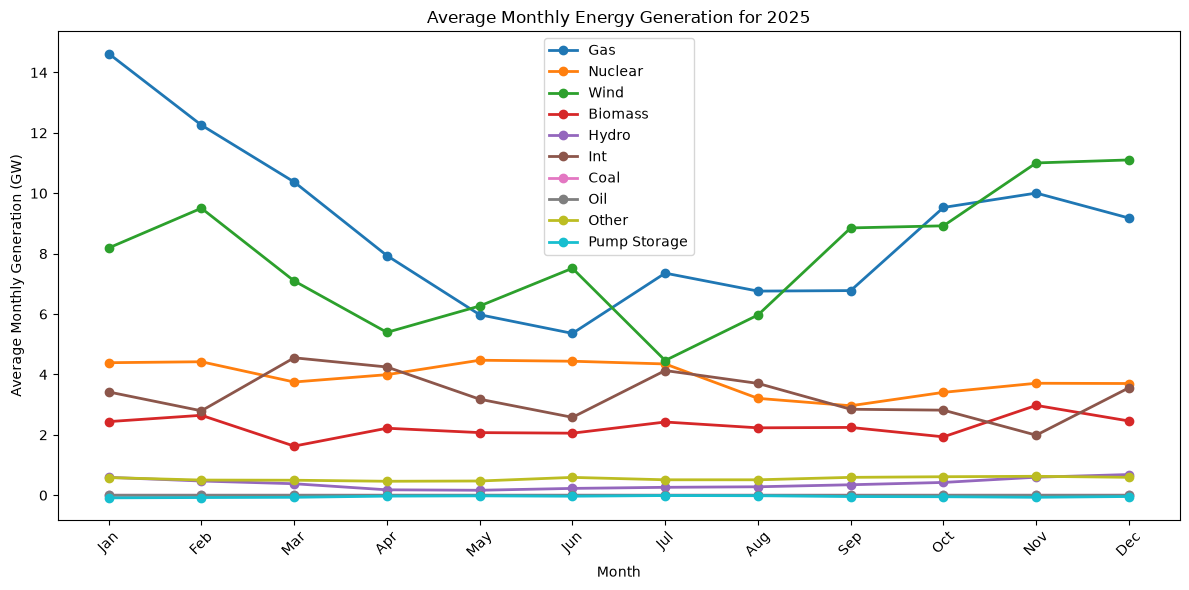

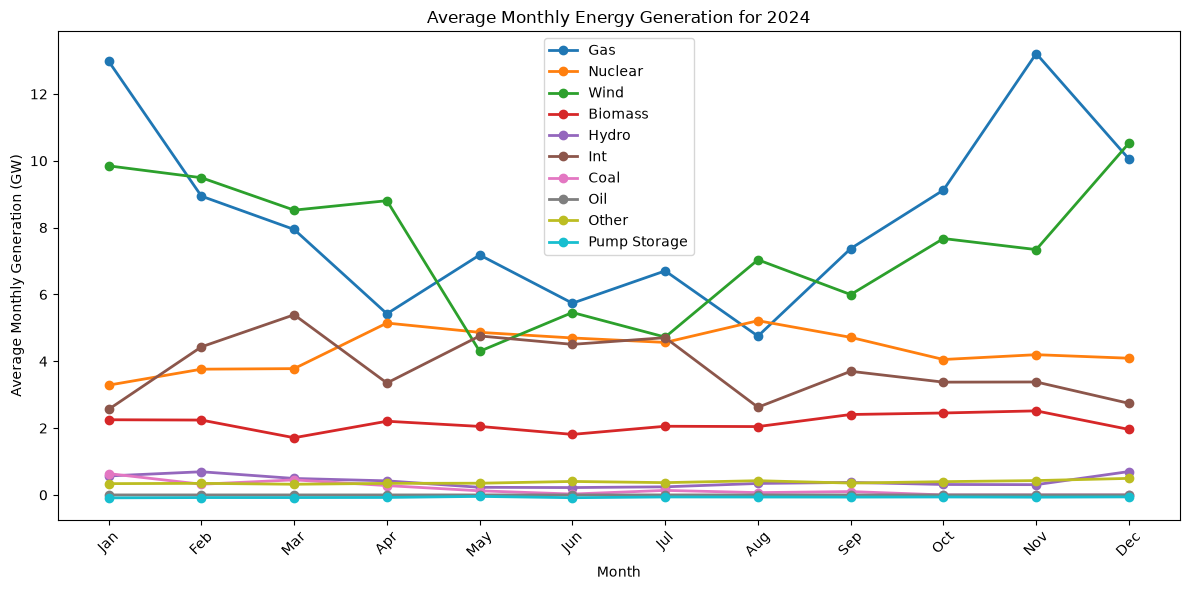

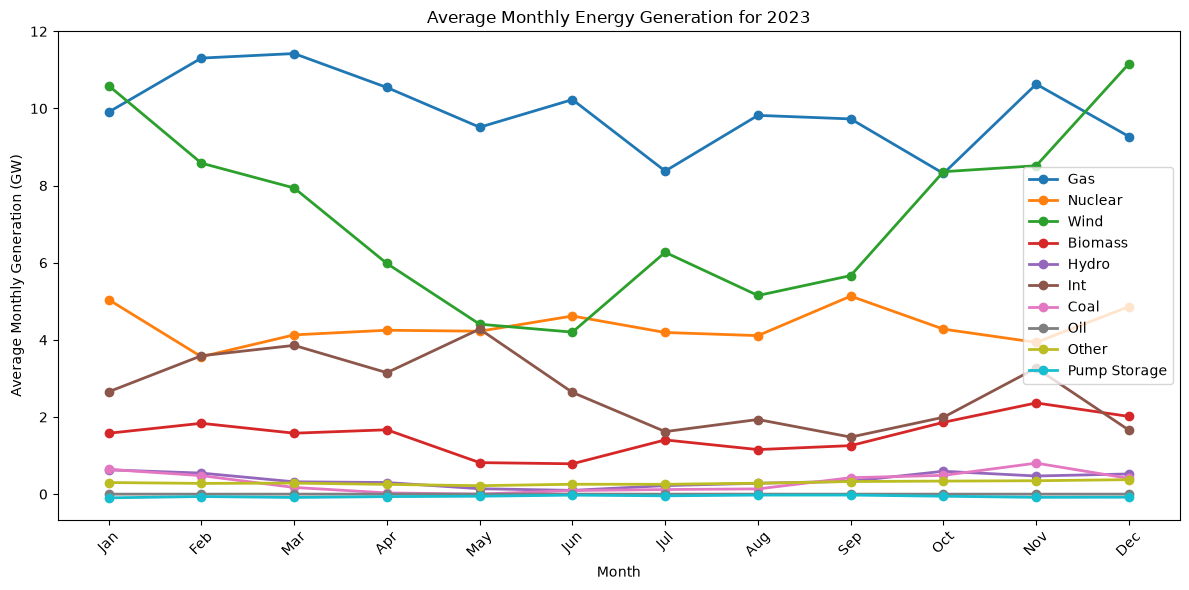

In [19]:
# meeting 4 tasks: plot monthly averages for a specific year

def plot_monthly_average_for_year(year):


    year_data = final_matrix_df.copy() # so matrix can be manipulated
    year_data['Date'] = pd.to_datetime(year_data['Date']) # converte to pandas dateime object for manipulation later
    
    # filter for the specific yea, month
    boolean_date_col = year_data['Date'].dt.year == int(year) # returns boolean column
    year_data = year_data[boolean_date_col] # want the full matrix where these rows are true
    year_data['MonthNum'] = year_data['Date'].dt.month

    

    # reset_index() turns 'MonthNum' back into normal column and now has a numerical index
    monthly_average = year_data.groupby('MonthNum').mean(numeric_only=True).reset_index()
    monthly_average = monthly_average.sort_values('MonthNum')
    #print(monthly_average.head())
    
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # create plot big enough
    plt.figure(figsize=(12, 6))
    
    fuels_to_plot = ['Gas', 'Nuclear', 'Wind', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage']
    
    for fuel in fuels_to_plot:
        x_values = monthly_average['MonthNum'] 
        y_values = monthly_average[fuel] / 1000 # convert to GW
        
        # draw a line with dots for each month
        plt.plot(x_values, y_values, label=fuel, linewidth=2, marker='o')
    
    # generate plots
    plt.title(f'Average Monthly Energy Generation for {year}')
    plt.ylabel('Average Monthly Generation (GW)')
    plt.xlabel('Month')
    plt.xticks(ticks=range(1, 13), labels=month_names, rotation=45)
    plt.yticks()
    plt.legend()
    plt.tight_layout() # ensures the tilted text doesn't get cut off at bottom
    plt.show()




#-----------------------------------------------------------------------

print('Yearly Monthly Average:')
print('-----------------------')
print('\n')

plot_monthly_average_for_year('2025') 
print('\n \n ')
plot_monthly_average_for_year('2024') 
print('\n \n')
plot_monthly_average_for_year('2023') 
print('\n \n')



In [2]:
# m4: combine data sets

# must combine neso files

file_paths = ['embedded_archive_2019.csv']
file_pathz = [
    'embedded_archive_2019.csv',
    'embedded_archive_2020.csv',
    'embedded_archive_2021.csv',
    'embedded_archive_2022.csv',
    'embedded_archive_2023.csv',
    'embedded_archive_2024.csv',
    'embedded_archive_2025.csv']

# hold all loaded dataframes as a list
all_neso_data = []

# loop through the list and read each file
for path in file_paths:
    temp_df = pd.read_csv(path)
    all_neso_data.append(temp_df)
    print(f' loaded {path}')

# combine them into one big dataframe
neso_df = pd.concat(all_neso_data, ignore_index=True) # to stack all datframes
print(f' loaded {len(file_paths)} files')


Loaded: embedded_archive_2019.csv
Successfully loaded 1 files.


In [40]:



# extract just the date from the Forecast_Datetime column
# neso_df['Forecast_Date'] = neso_df['Forecast_Datetime'].str.split('T') # creates column with a list of the split elemnts at T
neso_df['Forecast_Date'] = neso_df['Forecast_Datetime'].str.split('T').str[0] # then take first value in the list (the date)
neso_df['Settlement_Date'] = neso_df['SETTLEMENT_DATE'].str.split('T').str[0]
#print (neso_df.head())



# create a boolean column 
matching_dates = neso_df['Forecast_Date'] == neso_df['Settlement_Date']
#print(matching_dates.head())
neso_filtered = neso_df[matching_dates].copy() # only want the rows where this is true
#print (neso_filtered.head())
print(f' filtered {len(neso_filtered)} rows')


# rename columns
neso_filtered = neso_filtered.rename(columns={
    'SETTLEMENT_DATE': 'Date',
    'SETTLEMENT_PERIOD': 'Period',
    'EMBEDDED_WIND_FORECAST': 'Embedded_Wind',
    'EMBEDDED_WIND_CAPACITY': 'Wind_Capacity',
    'EMBEDDED_SOLAR_FORECAST': 'Solar',
    'EMBEDDED_SOLAR_CAPACITY': 'Solar_Capacity'})





# merge dataframes final_matrix_df and neso_filtered
neso_columns_to_keep = ['Date', 'Period', 'Embedded_Wind', 'Wind_Capacity', 'Solar', 'Solar_Capacity']
master_matrix = final_matrix_df.merge(
    neso_filtered[neso_columns_to_keep],
    on=['Date', 'Period'], # matching condition. since each date has 48 rows, need to introduce period
    how='left') # keep everything from my main left table (Table 1). if the right table doesn't have a match, just leave it blank
    # inner would delete a row from main table if there was a mismatch



# combine neso emb wind + elexxon grid wind (solar is just emb solar )
master_matrix['Wind'] = master_matrix['Wind'] + master_matrix['Embedded_Wind']
master_matrix = master_matrix.fillna(0) # replace NaN with 0
#print (master_matrix.head())




# find demand
fuels = ['Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage'] # these are the column names in the master matrix that we need to add
master_matrix['Demand'] = master_matrix[fuels].sum(axis=1) # sum horizontally
#print (master_matrix.head())




# choose the columns needed
final_columns = [
    'Date', 'Period',
    'Gas', 'Nuclear', 'Wind', 'Solar', 'Biomass', 
    'Hydro', 'Int', 'Coal', 'Oil', 'Other', 'Pump Storage',
    'Wind_Capacity', 'Solar_Capacity',
    'Demand'
]

# need rows with only those columns
master_matrix = master_matrix[final_columns].copy()
master_matrix = master_matrix.sort_values(['Date', 'Period']) # data may already be sorted

print('final combined matrix:')
print(master_matrix.head(96)) 

 filtered 112577 rows
final combined matrix:
          Date  Period      Gas  Nuclear  Wind  Solar  Biomass  Hydro     Int  \
0   2016-01-01       1   5716.0   8289.0   0.0    0.0      0.0  710.0  2756.0   
1   2016-01-01       2   6670.0   8292.0   0.0    0.0      0.0  659.0  2688.0   
2   2016-01-01       3   6985.0   8297.0   0.0    0.0      0.0  643.0  2742.0   
3   2016-01-01       4   6839.0   8285.0   0.0    0.0      0.0  642.0  2694.0   
4   2016-01-01       5   6775.0   8279.0   0.0    0.0      0.0  642.0  2554.0   
..         ...     ...      ...      ...   ...    ...      ...    ...     ...   
91  2016-01-02      44  10484.0   7785.0   0.0    0.0      0.0  792.0  2664.0   
92  2016-01-02      45   9476.0   7780.0   0.0    0.0      0.0  794.0  2682.0   
93  2016-01-02      46   8770.0   7783.0   0.0    0.0      0.0  792.0  2784.0   
94  2016-01-02      47   8117.0   7775.0   0.0    0.0      0.0  734.0  2168.0   
95  2016-01-02      48   4017.0   8075.0   0.0    0.0      0.0  

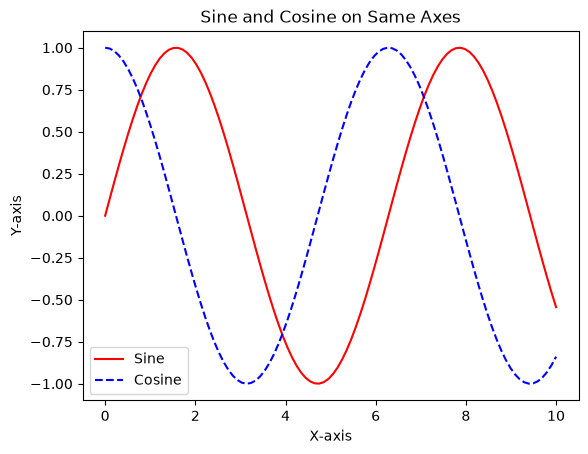

In [34]:
# test
# sample data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# create a single figure
plt.figure(figsize=(8, 5))

# overlay multiple plots on the same figure
plt.plot(x, y1, 'r-', label='Sine')
plt.plot(x, y2, 'b--', label='Cosine')

# add labels and a legend
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Sine and Cosine on Same Axes')
plt.legend()

plt.show()

# fig, ax = plt.subplots(figsize=(12, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
